## Define functions

In [5]:
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d

# --- Load Data ---
def load_data(file_path):
    """
    Loads timestamped accelerometer data from a CSV file.

    Args:
        file_path (str): Path to the input data file.

    Returns:
        pd.DataFrame: DataFrame containing columns ['x', 'y', 'z', 'timestamp'].
    """
    return pd.read_csv(file_path, names=['x', 'y', 'z', 'timestamp'])

# --- Interpolation Method ---
def align_by_interpolation(ref_df, align_df):
    """
    Aligns align_df to ref_df's timestamps using linear interpolation.

    Args:
        ref_df (pd.DataFrame): Reference dataframe with target timestamps.
        align_df (pd.DataFrame): Dataframe to align using interpolation.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (ref_df, interpolated_aligned_df)
    """
    interp_df = pd.DataFrame()
    interp_df['timestamp'] = ref_df['timestamp']
    interp_df['x'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['x'])
    interp_df['y'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['y'])
    interp_df['z'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['z'])
    interp_df = interp_df[['x', 'y', 'z', 'timestamp']]
    return ref_df, interp_df

# --- Save Aligned Data ---
def save_aligned_data(df_55, df_193, output_path):
    """
    Saves aligned data from two dataframes into a single CSV file in the order 55 then 193.

    Args:
        df_55 (pd.DataFrame): Aligned data from device 55.
        df_193 (pd.DataFrame): Aligned data from device 193.
        output_path (str): Path to save the output file.
    """
    aligned = pd.concat([df_55.add_suffix('_1'), df_193.add_suffix('_2')], axis=1)
    aligned.to_csv(output_path, index=False)
    print(f"Saved aligned data to {output_path}")

# --- Load, align and save ---
def load_align_save(distance):
    """
    Loads, aligns, and saves accelerometer data for multiple pairs of recordings,
    always saving in the order (55, 193) but aligning using the device with fewer samples.

    Args:
        distance (str): Distance label used in filenames (e.g., '50', '155').
    """
    for i in range(1, 6):
        df_55 = load_data(f'{distance}_{i}_55.txt')
        df_193 = load_data(f'{distance}_{i}_193.txt')

        # Prevent extrapolation by choosing the smaller one as reference
        if len(df_55) <= len(df_193):
            ref_df, aligned_df = align_by_interpolation(df_55, df_193)
        else:
            ref_df, aligned_df = align_by_interpolation(df_193, df_55)

        # Ensure df_55 is always saved as _1 and df_193 as _2
        if ref_df.equals(df_55):
            save_aligned_data(ref_df, aligned_df, f'aligned_{distance}_{i}.txt')
        else:
            save_aligned_data(aligned_df, ref_df, f'aligned_{distance}_{i}.txt')


def load_all_aligned_data_to_dict(file_prefixes):
    """
    Loads all aligned data files matching each prefix into a dictionary of DataFrames.
    
    Args:
        file_prefixes (List[str]): List of file name prefixes (e.g., ['263', 'static']).
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary of label -> DataFrame.
    """
    dfs = {}
    for prefix in file_prefixes:
        for i in range(1, 6):
            file_path = f'aligned_{prefix}_{i}.txt'
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, names=[
                    'x1', 'y1', 'z1', 'timestamp1', 'x2', 'y2', 'z2', 'timestamp2'
                ], dtype=str)  # Read as string first to avoid DtypeWarning

                # Convert all columns to numeric safely
                for col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                # Drop any rows with NaNs if needed
                df = df.dropna().reset_index(drop=True)

                key = f"{prefix}_{i}"
                dfs[key] = df
            else:
                print(f"File not found: {file_path}")
    return dfs


def load_dispersion_curve(filepath):
    df_disp = pd.read_csv(filepath)
    freqs_khz = df_disp.iloc[:, 0].values
    velocities_m_per_ms = df_disp.iloc[:, 1].values
    # Convert frequency to Hz and velocity to m/s
    return interp1d(freqs_khz * 1e3, velocities_m_per_ms * 1e3, bounds_error=False, fill_value="extrapolate")

In [52]:
import numpy as np
from scipy.signal import butter, filtfilt, correlate, stft, hilbert
import matplotlib.pyplot as plt

# --- Signal Processing Functions ---

def preamplify(data, gain_dB):
    gain = 10**(gain_dB / 20)
    return data * gain

def anti_alias_filter(data, cutoff_freq, Fs, order=4):
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='lowpass')
    return filtfilt(b, a, data)

def bandpass_filter(signal, fs, lowcut=30, highcut=1200, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def compute_rms_noise(static_data_dict):
    rms_list = []
    for df in static_data_dict.values():
        a1 = np.sqrt(((df['x1']-16.25)/256)**2 + ((df['y1']+7.4)/256)**2 + ((df['z1']-252.8)/256)**2)
        a2 = np.sqrt(((df['x2']-21.3)/256)**2 + ((df['y2']+20.72)/256)**2 + ((df['z2']-188)/256)**2)
        rms_list.append(np.mean(np.sqrt(a1**2 + a2**2)))
    return np.mean(rms_list), np.std(rms_list)

def find_event(signal, threshold):
    energy = np.abs(signal)
    if np.max(energy) < threshold:
        return None
    return np.argmax(energy)

# def extract_event_window(signal, event_index, window_size_samples):
#     start = max(event_index - window_size_samples // 2, 0)
#     end = min(event_index + window_size_samples // 2, len(signal))
#     return signal[start:end]

def cross_correlate_signals(sig1, sig2, fs):
    corr = correlate(sig2, sig1, mode='full')
    lags = np.arange(-len(sig1) + 1, len(sig2)) / fs
    delay = lags[np.argmax(corr)]
    return corr, lags, delay

# --- Analysis Function ---

from collections import defaultdict

def extract_event_window(signal, event_index, window_size_samples):
    half = window_size_samples // 2
    start = event_index - half
    end = event_index + half

    if start < 0:
        pad_left = np.zeros(-start)
        signal = np.concatenate([pad_left, signal[:end]])
    elif end > len(signal):
        pad_right = np.zeros(end - len(signal))
        signal = np.concatenate([signal[start:], pad_right])
    else:
        signal = signal[start:end]

    return signal[:window_size_samples]


def compute_envelope(signal):
    analytic_signal = hilbert(signal)
    envelope = np.abs(analytic_signal)
    return envelope

def analyze_with_top5_events(data_dict, static_dict, dispersion_path='pvc_dispersion_curve_L.csv', Fs=3200, window_sec=1, slide_sec=0.2, gain_dB=20):
    from collections import defaultdict

    sensor_distance = 3.5
    get_velocity = load_dispersion_curve(dispersion_path)
    noise_mean, noise_std = compute_rms_noise(static_dict)
    threshold = noise_mean + 5 * noise_std

    window_size = int(window_sec * Fs)
    slide_size = int(slide_sec * Fs)

    results = {}

    for label, df in data_dict.items():
        prefix = label.split('_')[0]

        a1 = np.sqrt(((df['x1'] - 16.25) / 256) ** 2 + ((df['y1'] + 7.4) / 256) ** 2 + ((df['z1'] - 252.8) / 256) ** 2)
        a2 = np.sqrt(((df['x2'] - 21.3) / 256) ** 2 + ((df['y2'] + 20.72) / 256) ** 2 + ((df['z2'] - 188) / 256) ** 2)

        a1 = bandpass_filter(anti_alias_filter(preamplify(a1, gain_dB), 1400, Fs), Fs)
        a2 = bandpass_filter(anti_alias_filter(preamplify(a2, gain_dB), 1400, Fs), Fs)

        event_candidates = []

        for start in range(0, len(a1) - window_size + 1, slide_size):
            win1 = a1[start:start + window_size]
            win2 = a2[start:start + window_size]

            idx1 = find_event(win1, threshold)
            idx2 = find_event(win2, threshold)
            if idx1 is None or idx2 is None:
                continue

            ev1 = extract_event_window(win1, idx1, window_size)
            ev2 = extract_event_window(win2, idx2, window_size)

            env1 = compute_envelope(ev1)
            env2 = compute_envelope(ev2)

            if np.max(env1) < threshold or np.max(env2) < threshold:
                continue

            f, t, Zxx = stft(ev1, fs=Fs, nperseg=256, noverlap=128)
            power = np.abs(Zxx).mean(axis=1)
            dominant_freq = f[np.argmax(power)] if len(power) > 0 else None

            if dominant_freq is None or dominant_freq < 1:
                continue

            velocity = float(get_velocity(dominant_freq))
            max_delay = sensor_distance / velocity

            corr, lags, delay = cross_correlate_signals(env1, env2, Fs)
            peak = np.max(np.abs(corr))
            mean_corr = np.mean(np.abs(corr))
            ratio = peak / mean_corr if mean_corr > 0 else 0

            if ratio < 5 or abs(delay) > max_delay:
                continue

            est_loc = sensor_distance / 2 - velocity * delay

            event_candidates.append({
                'delay': delay,
                'location': est_loc,
                'peak': peak,
                'corr': corr,
                'lags': lags,
                'ev1': ev1,
                'f': f,
                't': t,
                'Zxx': Zxx
            })

        if not event_candidates:
            print(f"[{prefix}] No valid events.")
            continue

        top_events = sorted(event_candidates, key=lambda e: e['peak'], reverse=True)[:5]
        avg_delay = np.mean([e['delay'] for e in top_events])
        avg_loc = np.mean([e['location'] for e in top_events])
        results[prefix] = (avg_delay, avg_loc)

        print(f"[{prefix}] Avg Delay from Top 5 Events: {avg_delay:.6f}s -> Est. Location: {avg_loc:.2f} m")

        # Plot average cross-correlation of top 5
        plt.figure(figsize=(10, 6))

        corr_stack = [e['corr'] for e in top_events]
        lags = top_events[0]['lags']
        mean_corr = np.mean(corr_stack, axis=0)
        best_idx = np.argmax(np.abs(mean_corr))
        best_delay = lags[best_idx]

        plt.subplot(211)
        plt.plot(lags, mean_corr)
        plt.axvline(best_delay, color='red', linestyle='--', label=f'Peak = {best_delay:.4f}s')
        plt.title(f'{prefix} - Avg Cross-Correlation (Top 5 Events)')
        plt.xlabel('Lag (s)')
        plt.ylabel('Correlation')
        plt.grid(True)
        plt.legend()

        # Plot STFT of top event
        top_event = top_events[0]
        f, t, Zxx = top_event['f'], top_event['t'], top_event['Zxx']

        plt.subplot(212)
        plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
        plt.title(f'{prefix} - STFT of Strongest Event')
        plt.ylabel('Frequency (Hz)')
        plt.xlabel('Time (s)')
        plt.tight_layout()
        plt.show()

    return results


## Import and Align data

In [ ]:
import pandas as pd

# load_align_save(263)
# load_align_save(155)
# load_align_save(50)
# load_align_save('static')

Saved aligned data to aligned_263_1.txt
Saved aligned data to aligned_263_2.txt
Saved aligned data to aligned_263_3.txt
Saved aligned data to aligned_263_4.txt
Saved aligned data to aligned_263_5.txt
Saved aligned data to aligned_155_1.txt
Saved aligned data to aligned_155_2.txt
Saved aligned data to aligned_155_3.txt
Saved aligned data to aligned_155_4.txt
Saved aligned data to aligned_155_5.txt


## Analyze data and Plotting

In [7]:
file_prefixes = ['263', '155', '50']
static_prefixes = ['static']

data_dict = load_all_aligned_data_to_dict(file_prefixes)
static_dict = load_all_aligned_data_to_dict(static_prefixes)

[263] Avg Delay from Top 5 Events: 0.000937s -> Est. Location: 0.27 m


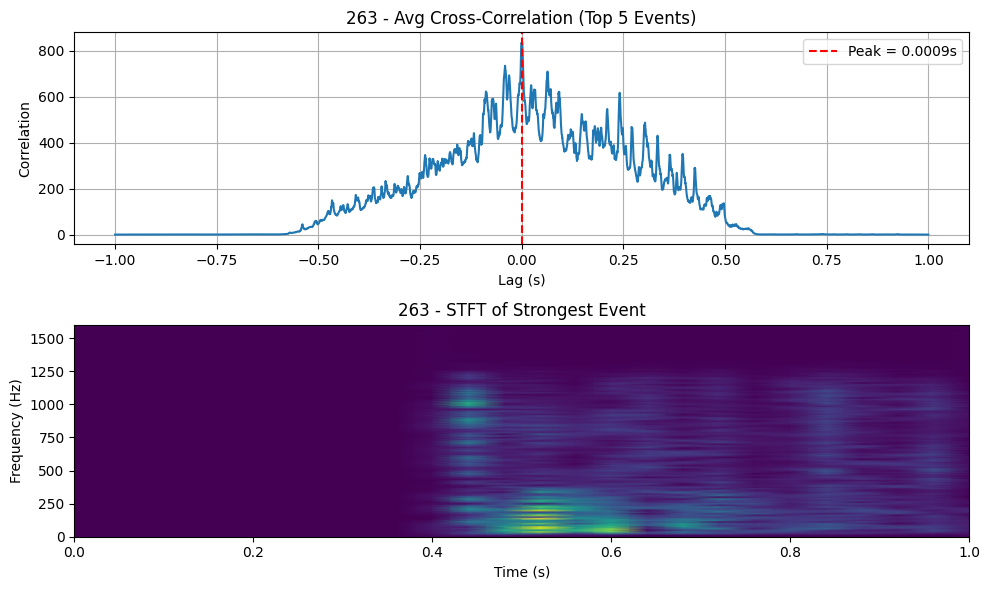

[263] Avg Delay from Top 5 Events: 0.000156s -> Est. Location: 1.50 m


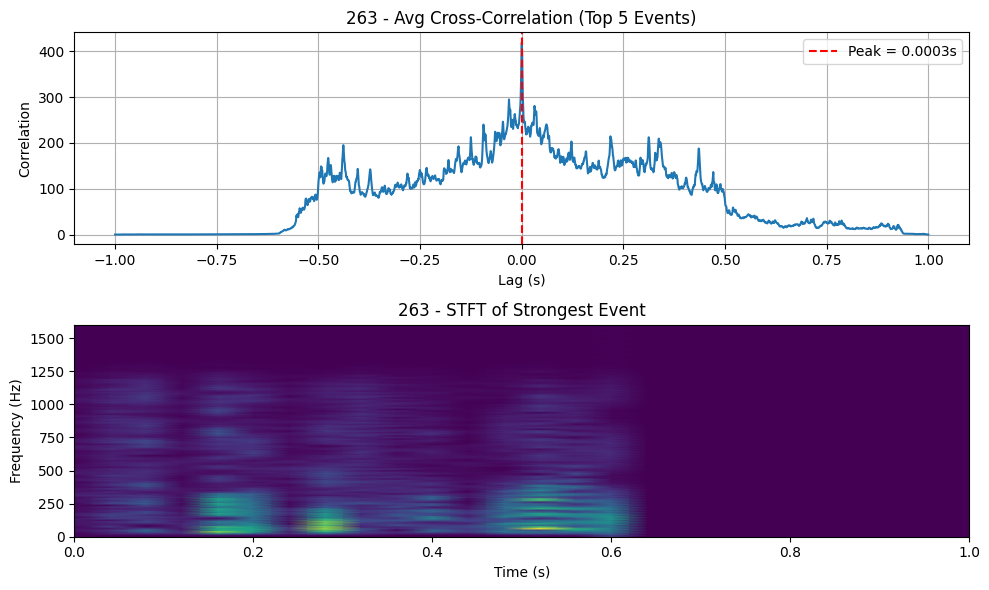

[263] No valid events.
[263] Avg Delay from Top 5 Events: 0.000000s -> Est. Location: 1.75 m


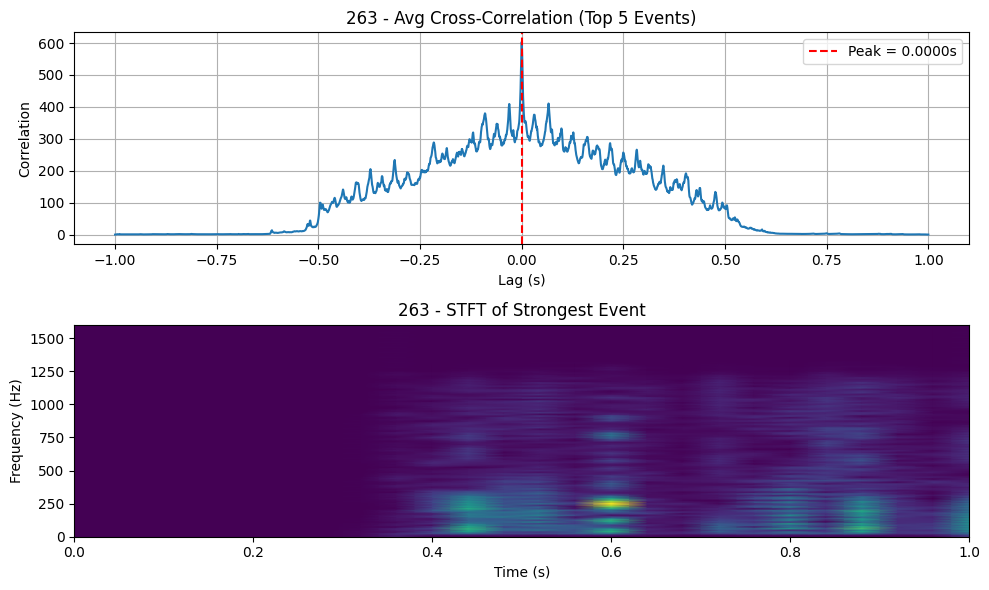

[263] Avg Delay from Top 5 Events: 0.000156s -> Est. Location: 1.50 m


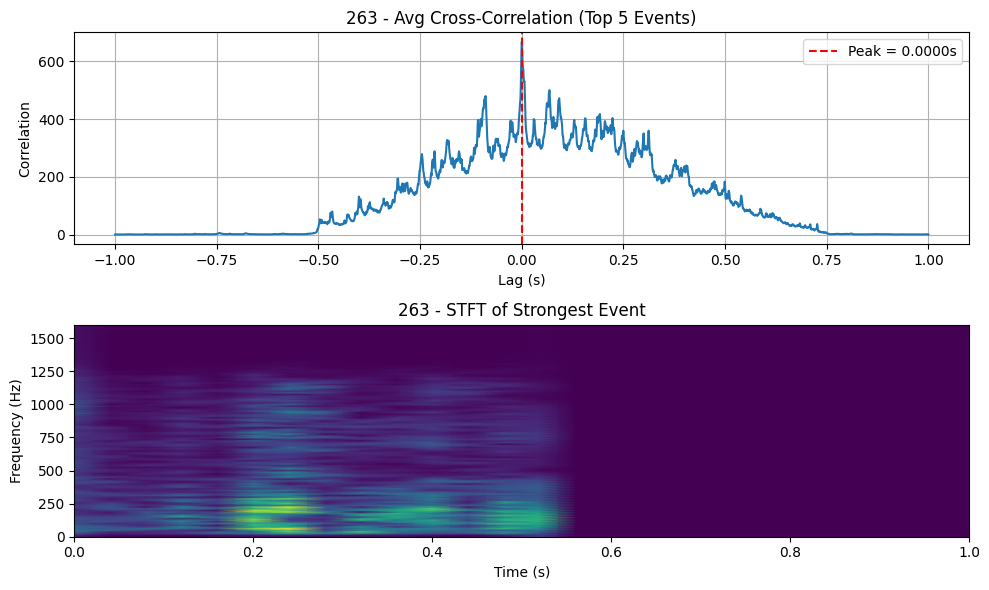

[155] No valid events.
[155] Avg Delay from Top 5 Events: 0.000156s -> Est. Location: 1.50 m


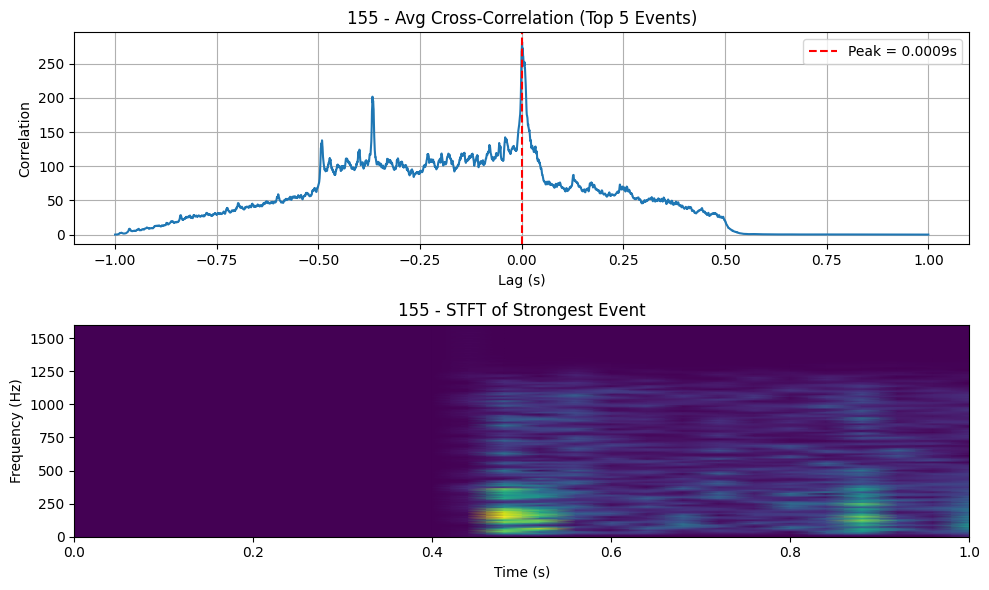

[155] Avg Delay from Top 5 Events: 0.000313s -> Est. Location: 1.26 m


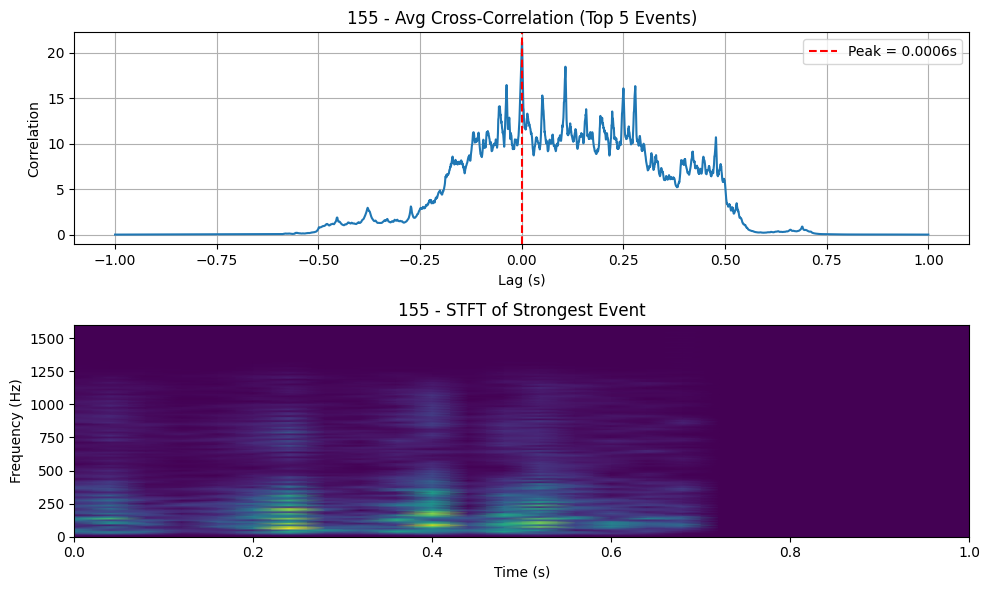

[155] Avg Delay from Top 5 Events: -0.000250s -> Est. Location: 2.15 m


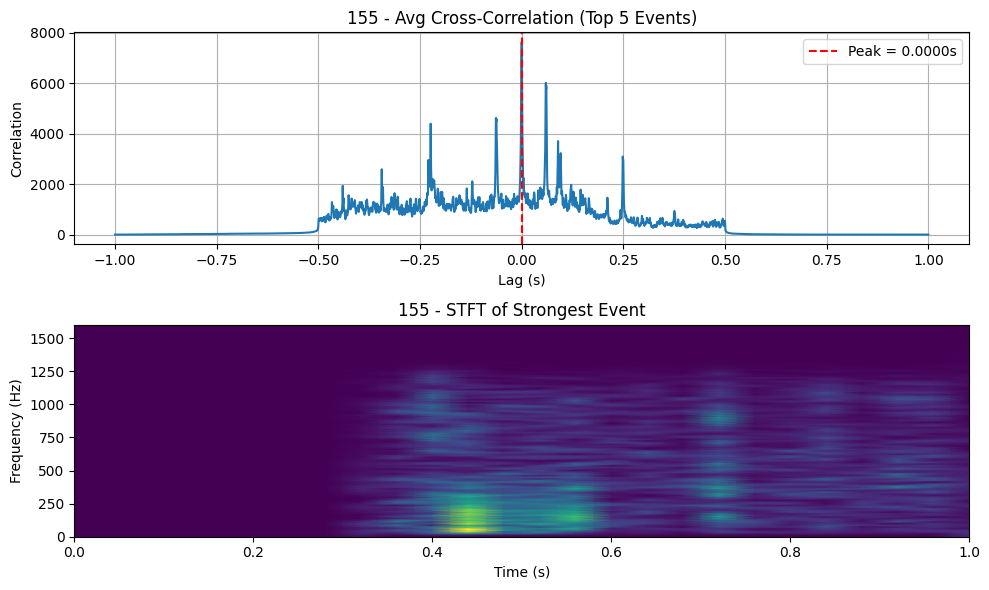

[155] No valid events.
[50] No valid events.
[50] No valid events.
[50] No valid events.
[50] Avg Delay from Top 5 Events: 0.000469s -> Est. Location: 1.01 m


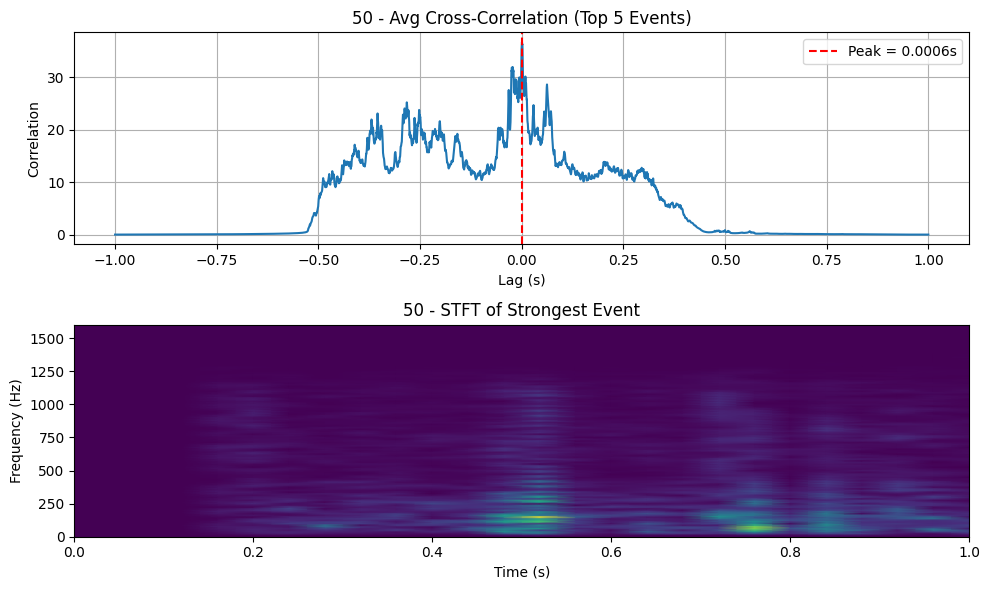

[50] No valid events.


In [53]:
results = analyze_with_top5_events(data_dict, static_dict)